# Exercise 1: Home Value Estimation — California Housing

## Context

You've joined a small analytics team building a home-value estimation tool for California. Leadership wants a first-pass model before committing more resources, plus an honest read on how much to trust it.

## Data handed over

Census block groups from the 1990 U.S. Census, built into scikit-learn (`fetch_california_housing`) — no download needed. Feature selection has already been done by the team: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, and location were judged relevant to home valuation before this data reached you. You don't need to go hunting for which raw signals matter — though whether this set is sufficient, or has more than it needs, is fair to revisit once you've seen how a first model performs.

- **MedInc** — median income in the block group (tens of thousands of USD)
- **HouseAge** — median house age
- **AveRooms** / **AveBedrms** — average rooms / bedrooms per household
- **Population** — block group population
- **AveOccup** — average household occupancy
- **Latitude** / **Longitude** — location

**Target: MedHouseVal** — median house value for the block group, in hundreds of thousands of USD.

## Objective

Produce a first model, and report how good it actually is — including anything about the data itself that could make predictions misleading if ignored. No metric has been decided yet; that's part of the job.

## Approach

**Model zero.** Feature curation is the team's job, already done — skip feature engineering and selection. Before fitting anything, do an integrity pass on both the target *and* the features: shape, dtypes, missing values, and a quick look at every variable's distribution — not to decide transforms yet, just to catch anything that would make a fit untrustworthy (a hidden cap, an impossible value, an extreme outlier). That's different from asking "is this feature skewed enough to need a log transform" or "are two features collinear" — those are modeling decisions, and they get made *after* model zero, driven by its actual residuals, not by eyeballing a histogram shape in isolation. Then: fit the simplest model on every feature as-is, and let its errors — not speculation — drive whatever comes next.

## 1. Load the data and split before touching anything

Splitting first, before any EDA or feature engineering, so nothing we decide later is contaminated by having seen the test set.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (16512, 8), test: (4128, 8)


## 2. Sanity check before fitting anything

Integrity, not engineering: dtypes, missing values, and the distribution of every variable — target included. Looking for anything that would make a fit untrustworthy, not deciding transforms yet.

In [2]:
print("dtypes:")
print(X_train.dtypes)
print()
print("missing values — features:", int(X_train.isna().sum().sum()))
print("missing values — target:  ", int(y_train.isna().sum()))
print()
print("feature summary:")
print(X_train.describe())
print()
print("target summary:")
print(y_train.describe())

dtypes:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

missing values — features: 0
missing values — target:   0

feature summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  16512.000000  16512.000000  16512.000000  16512.000000  16512.000000   
mean       3.880754     28.608285      5.435235      1.096685   1426.453004   
std        1.904294     12.602499      2.387375      0.433215   1137.056380   
min        0.499900      1.000000      0.888889      0.333333      3.000000   
25%        2.566700     18.000000      4.452055      1.006508    789.000000   
50%        3.545800     29.000000      5.235874      1.049286   1167.000000   
75%        4.773175     37.000000      6.061037      1.100348   1726.000000   
max       15.000100     52.000000    141.909091     25.636364  35682.000000   

           Av

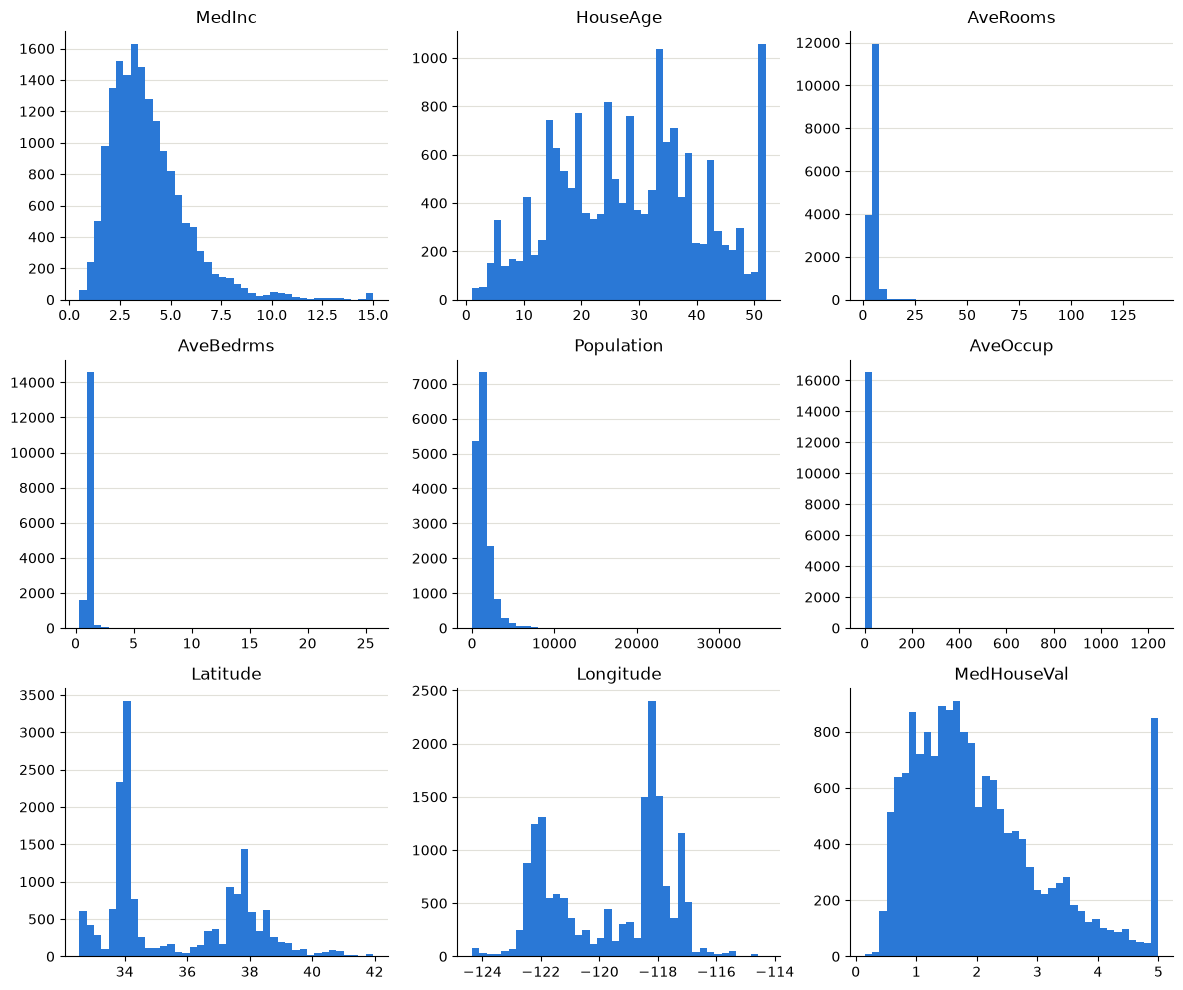

In [3]:
import matplotlib.pyplot as plt

data = X_train.copy()
data["MedHouseVal"] = y_train

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, data.columns):
    ax.hist(data[col], bins=40, color="#2a78d6")
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()

## 3. Trivial baseline: predict the mean, always

The floor any real model has to clear. If a model can't beat "just guess the average price every time" by a wide margin, something's wrong.

In [3]:
import numpy as np

naive_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
naive_residuals = naive_pred - y_test.values  # predicted - actual, in $100k units

print("naive baseline residuals (predicted - actual):")
print(pd.Series(naive_residuals).describe())

naive baseline residuals (predicted - actual):
count    4128.000000
mean        0.016944
std         1.144870
min        -2.928063
25%        -0.558053
50%         0.285447
75%         0.879197
max         1.921957
dtype: float64


## 4. Real baseline: plain linear regression, all raw features, zero engineering

No dropped columns, no transforms, no scaling (OLS doesn't need it — scaling only matters for regularized/gradient-descent-based fitting, which comes later). The point isn't a good score, it's a number to react to.

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
residuals = pred - y_test.values  # predicted - actual, in $100k units

print("baseline linear regression residuals (predicted - actual):")
print(pd.Series(residuals).describe())

baseline linear regression residuals (predicted - actual):
count    4128.000000
mean       -0.003479
std         0.745664
min        -4.148388
25%        -0.312442
50%         0.122439
75%         0.460935
max         9.875331
dtype: float64


## 5. Look at the actual error distribution before choosing how to report it

No metric committed to yet — just the raw residuals, side by side, for both baselines.

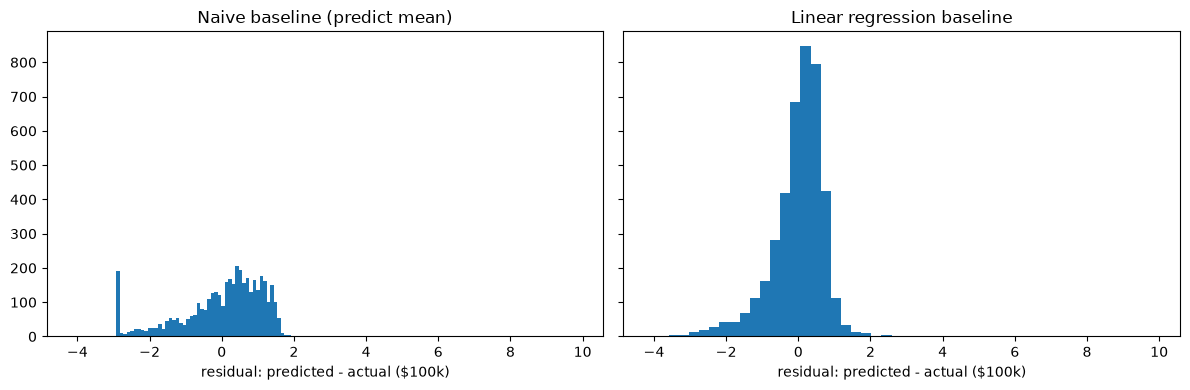

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(naive_residuals, bins=50)
axes[0].set_title("Naive baseline (predict mean)")
axes[0].set_xlabel("residual: predicted - actual ($100k)")

axes[1].hist(residuals, bins=50)
axes[1].set_title("Linear regression baseline")
axes[1].set_xlabel("residual: predicted - actual ($100k)")

plt.tight_layout()
plt.show()

## 6. Two real issues the residuals reveal

The linear regression residuals are heavy-tailed and asymmetric (min -4.15, max **+9.88** — that's a $988k miss on a single house). Two distinct, genuine causes, not one:

**(a) Target censoring.** `MedHouseVal` is capped at exactly 5.00001 — any block group truly worth more got clipped to that value in the data itself. This doesn't just distort evaluation on capped points, it distorts *training*: the model is fit on labels that are already wrong for ~4.7% of the data.

**(b) A handful of extreme leverage points.** `AveRooms`/`AveBedrms` are *ratios* (total rooms / households). A block group with only a handful of households can produce an absurd ratio from ordinary arithmetic. That's what's driving the single worst prediction below.

In [7]:
# (a) Target censoring: how much of the data sits exactly at the cap, and
# how biased is the model specifically on those points?
capped_mask = (y_test.values == y.max())
print(f"capped points in test set: {capped_mask.sum()} / {len(y_test)} ({capped_mask.mean():.1%})")
print()
print("residuals AT the cap:")
print(pd.Series(residuals[capped_mask]).describe())
print()
print("residuals everywhere else:")
print(pd.Series(residuals[~capped_mask]).describe())

capped points in test set: 179 / 4128 (4.3%)

residuals AT the cap:
count    179.000000
mean      -1.128152
std        1.379678
min       -4.148388
25%       -2.207698
50%       -1.190934
75%       -0.204870
max        2.260283
dtype: float64

residuals everywhere else:
count    3949.000000
mean        0.047500
std         0.659888
min        -3.632784
25%        -0.259281
50%         0.141655
75%         0.468142
max         9.875331
dtype: float64


In [8]:
# (b) The single worst prediction — is it the AveRooms/AveBedrms ratio artifact?
worst_idx = residuals.argmax()
print(f"predicted: {pred[worst_idx]:.3f}   actual: {y_test.values[worst_idx]:.3f}")
print()
print("feature values for this row, and where they rank against the training set:")
row = X_test.iloc[worst_idx]
for col in X_test.columns:
    pctile = (X_train[col] < row[col]).mean() * 100
    print(f"  {col:12s} = {row[col]:10.3f}   ({pctile:5.1f}th percentile)")

predicted: 11.500   actual: 1.625

feature values for this row, and where they rank against the training set:
  MedInc       =      4.625   ( 72.5th percentile)
  HouseAge     =     34.000   ( 62.0th percentile)
  AveRooms     =    132.533   (100.0th percentile)
  AveBedrms    =     34.067   (100.0th percentile)
  Population   =     36.000   (  0.3th percentile)
  AveOccup     =      2.400   ( 23.3th percentile)
  Latitude     =     38.800   ( 94.3th percentile)
  Longitude    =   -120.080   ( 39.7th percentile)
